<a href="https://colab.research.google.com/github/kalaicoder14/TASK_05_Ecommerce_Return_Rate_Investigation/blob/main/task_05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
# load dataset
data=pd.read_csv("/content/ecommerce_customer_data_custom_ratios.csv")

In [3]:
#head
data.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,08-09-2020 9.38,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0.0
1,46251,05-03-2022 12.56,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0.0
2,46251,23-05-2022 18.18,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0.0
3,46251,12-11-2020 13.13,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0.0
4,13593,27-11-2020 17.55,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1.0


In [6]:
# dimensions
data.shape

(247062, 13)

In [7]:
# info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247062 entries, 0 to 247061
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            247062 non-null  int64  
 1   Purchase Date          247062 non-null  object 
 2   Product Category       247062 non-null  object 
 3   Product Price          247062 non-null  int64  
 4   Quantity               247062 non-null  int64  
 5   Total Purchase Amount  247062 non-null  int64  
 6   Payment Method         247062 non-null  object 
 7   Customer Age           247062 non-null  int64  
 8   Returns                200031 non-null  float64
 9   Customer Name          247062 non-null  object 
 10  Age                    247062 non-null  int64  
 11  Gender                 247061 non-null  object 
 12  Churn                  247061 non-null  float64
dtypes: float64(2), int64(6), object(5)
memory usage: 24.5+ MB


In [8]:
# missing values
data.isnull().sum()

,0
Customer ID,0
Purchase Date,0
Product Category,0
Product Price,0
Quantity,0
Total Purchase Amount,0
Payment Method,0
Customer Age,0
Returns,47031
Customer Name,0


In [9]:
# Handle missing values in Returns
data['Returns'] = data['Returns'].fillna(0)

In [11]:
# Fill missing values for Gender and Churn

data['Gender'] = data['Gender'].fillna(
    data['Gender'].mode()[0]
)

data['Churn'] = data['Churn'].fillna(
    data['Churn'].mode()[0]
)

# Check result
print(data[['Gender', 'Churn']].isnull().sum())

Gender    0
Churn     0
dtype: int64


In [12]:
total_orders = len(data)
returned_orders = (data['Returns'] == 1).sum()
return_percentage = (returned_orders / total_orders) * 100

print("\nTotal Orders:", total_orders)
print("Returned Orders:", returned_orders)
print("Return Percentage:", round(return_percentage, 2), "%")


Total Orders: 247062
Returned Orders: 99635
Return Percentage: 40.33 %


In [13]:
# mean,median,std varaition,min,max,Quartiles
data.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,247062.000000,247062.000000,247062.000000,247062.000000,247062.000000,247062.000000,247062.000000,247062.000000
mean,25006.244639,254.732804,2.999138,2725.216658,43.951077,0.403279,43.951077,0.199610
std,14424.991461,141.571737,1.414684,1442.840127,15.349272,0.490557,15.349272,0.399708
min,1.000000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12499.000000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25029.000000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37504.000000,378.000000,4.000000,3973.000000,57.000000,1.000000,57.000000,0.000000
max,50000.000000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [14]:
print("\nProduct Price Statistics")
print(data['Product Price'].describe())

print("\nCustomer Age Statistics")
print(data['Customer Age'].describe())

print("\nPurchase Amount Statistics")
print(data['Total Purchase Amount'].describe())

print("\nMean Product Price:", data['Product Price'].mean())
print("Median Product Price:", data['Product Price'].median())
print("Std Product Price:", data['Product Price'].std())



Product Price Statistics
count    247062.000000
mean        254.732804
std         141.571737
min          10.000000
25%         132.000000
50%         255.000000
75%         378.000000
max         500.000000
Name: Product Price, dtype: float64

Customer Age Statistics
count    247062.000000
mean         43.951077
std          15.349272
min          18.000000
25%          31.000000
50%          44.000000
75%          57.000000
max          70.000000
Name: Customer Age, dtype: float64

Purchase Amount Statistics
count    247062.000000
mean       2725.216658
std        1442.840127
min         100.000000
25%        1477.000000
50%        2724.000000
75%        3973.000000
max        5350.000000
Name: Total Purchase Amount, dtype: float64

Mean Product Price: 254.73280391156877
Median Product Price: 255.0
Std Product Price: 141.57173671709666


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

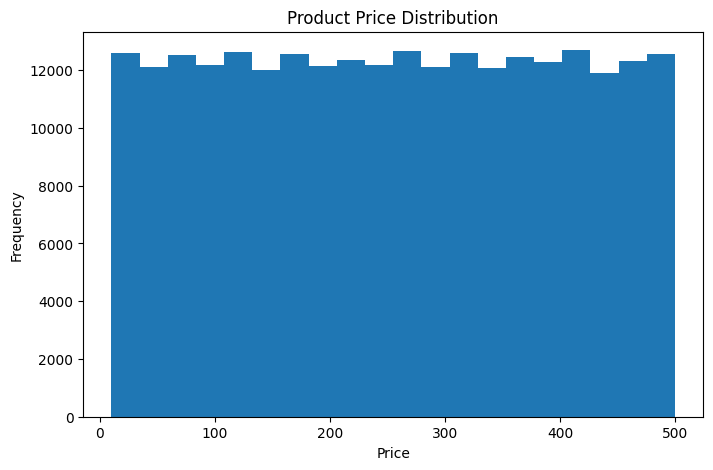

In [16]:
# Histogram
plt.figure(figsize=(8,5))
plt.hist(data['Product Price'], bins=20)
plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

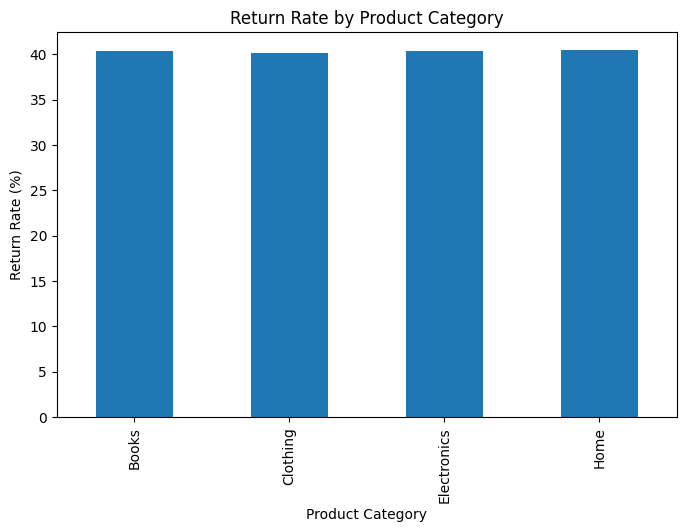


Category Return Rates:
Product Category
Home           40.419222
Electronics    40.407686
Books          40.389317
Clothing       40.152822
Name: Returns, dtype: float64


In [17]:
# Category vs Return Rate
category_return = data.groupby('Product Category')['Returns'].mean()*100

plt.figure(figsize=(8,5))
category_return.plot(kind='bar')
plt.title("Return Rate by Product Category")
plt.ylabel("Return Rate (%)")
plt.show()

print("\nCategory Return Rates:")
print(category_return.sort_values(ascending=False))

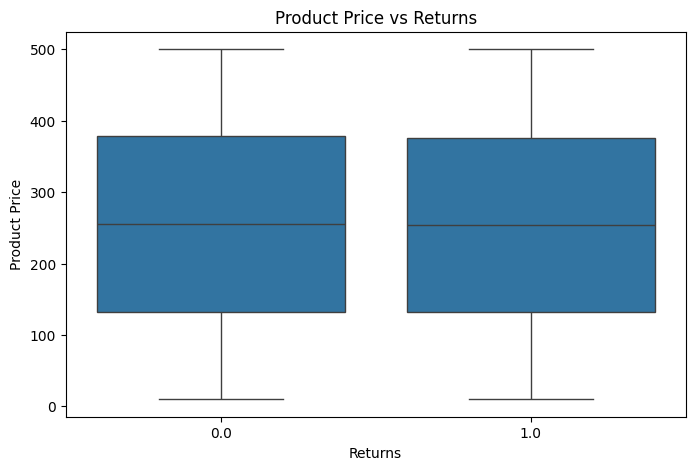

In [18]:
# Price vs Return
plt.figure(figsize=(8,5))
sns.boxplot(x='Returns', y='Product Price', data=data)
plt.title("Product Price vs Returns")
plt.show()

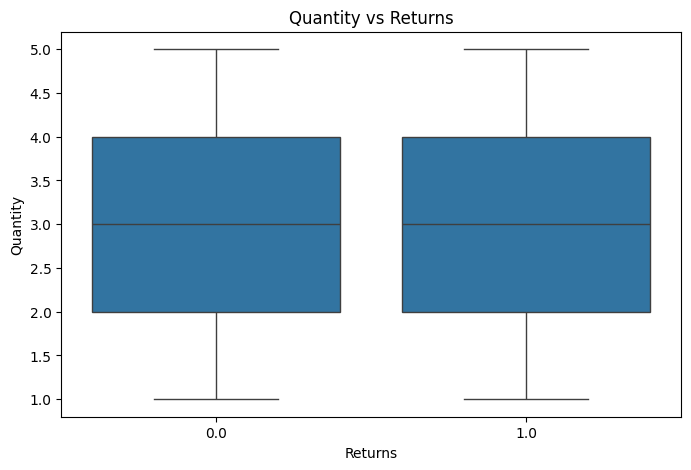

In [19]:
# Quantity vs Return
plt.figure(figsize=(8,5))
sns.boxplot(x='Returns', y='Quantity', data=data)
plt.title("Quantity vs Returns")
plt.show()

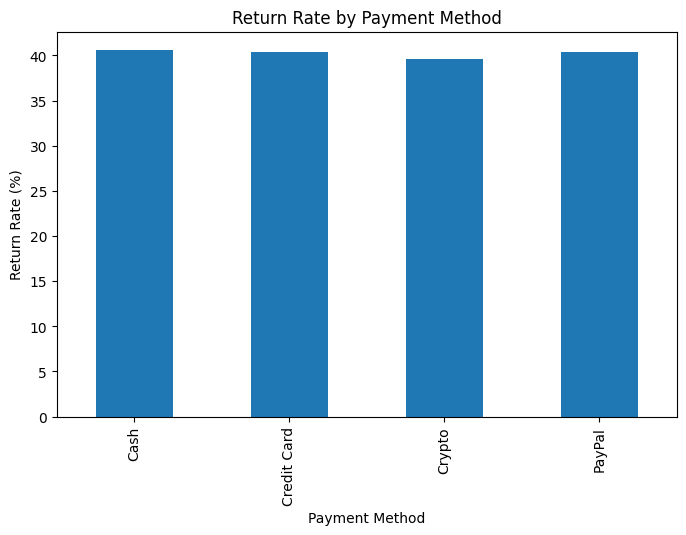

In [20]:
# Payment Method vs Return
payment_return = data.groupby('Payment Method')['Returns'].mean()*100
plt.figure(figsize=(8,5))
payment_return.plot(kind='bar')
plt.title("Return Rate by Payment Method")
plt.ylabel("Return Rate (%)")
plt.show()


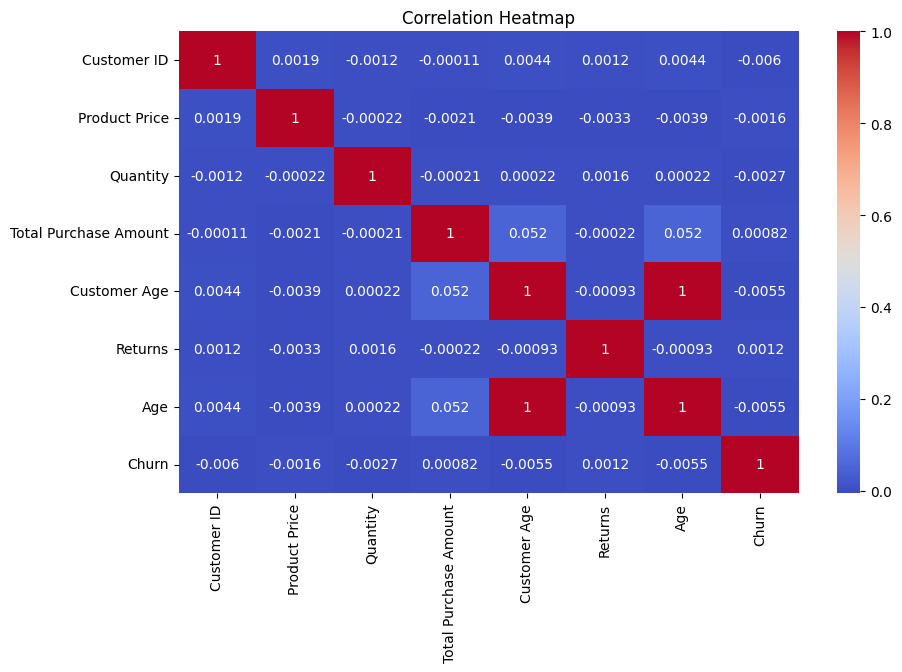

In [21]:
# Correlation Heatmap
numeric_df = data.select_dtypes(include=np.number)
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Number of Price Outliers: 0


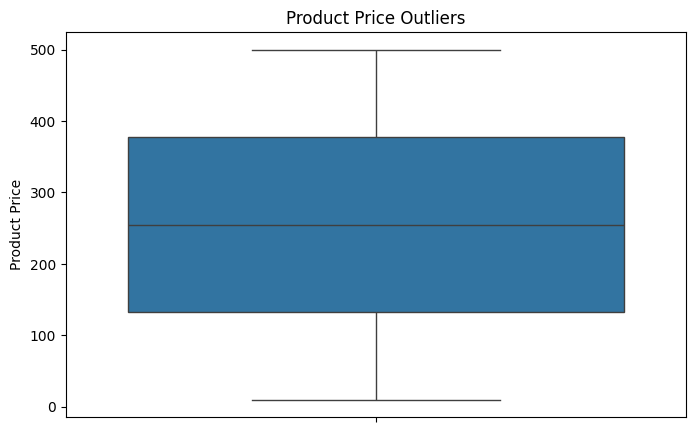

In [22]:
Q1 = data['Product Price'].quantile(0.25)
Q3 = data['Product Price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = data[(data['Product Price'] < lower) |
              (data['Product Price'] > upper)]
print("\nNumber of Price Outliers:", len(outliers))
plt.figure(figsize=(8,5))
sns.boxplot(y=data['Product Price'])
plt.title("Product Price Outliers")
plt.show()

In [23]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(
    data['Product Category'],
    data['Returns']
)

# Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency_table)
print("\nChi-Square Test")
print("Chi2 Statistic:", chi2)
print("P-value:", p)
if p < 0.05:
    print("Reject H0")
    print("Product Category significantly affects Returns")
else:
    print("Fail to Reject H0")
    print("No significant relationship found")


Chi-Square Test
Chi2 Statistic: 1.3630394699846007
P-value: 0.7142208866862612
Fail to Reject H0
No significant relationship found


In [ ]:
# Customer Segmentation
customer_returns = data.groupby('Customer ID')['Returns'].sum()
high_return_customers = customer_returns[
    customer_returns >= 2
]
print("\nHigh Return Customers:")
print(high_return_customers.head())
premium_customers = data[
    data['Total Purchase Amount'] >
    data['Total Purchase Amount'].quantile(0.75)
]
print("\nPremium Customers Count:",
      premium_customers['Customer ID'].nunique())


High Return Customers:
Customer ID
1350    3.0
2919    3.0
3443    6.0
3576    5.0
3843    4.0
Name: Returns, dtype: float64

Premium Customers Count: 61


In [24]:
#  Business Insights
highest_category = category_return.idxmax()
print(f"Highest Return Category: {highest_category}")
print("Product category appears to be a major factor influencing returns.")
print("High-return customers should be monitored.")
print("Premium customers require special retention strategies.")
print("Focus on categories with the highest return rates to reduce losses.")

Highest Return Category: Home
Product category appears to be a major factor influencing returns.
High-return customers should be monitored.
Premium customers require special retention strategies.
Focus on categories with the highest return rates to reduce losses.


In [25]:
# Operations Team Recommendations
print("\n OPERATIONS RECOMMENDATIONS ")
# Highest return category
category_return = data.groupby('Product Category')['Returns'].mean() * 100
highest_category = category_return.idxmax()
# High return customers
high_return_customers = data.groupby('Customer ID')['Returns'].sum()
high_return_count = len(high_return_customers[high_return_customers >= 2])
print(f"1. Focus on reducing returns in the '{highest_category}' category.")
print("2. Strengthen product quality checks before shipping.")
print("3. Improve product descriptions and images to set accurate expectations.")
print(f"4. Monitor {high_return_count} customers with frequent returns.")
print("5. Review inventory planning for products with high return rates.")
print("6. Analyze return patterns regularly and take corrective actions.")
print("7. Provide better customer support to reduce avoidable returns.")


 OPERATIONS RECOMMENDATIONS 
1. Focus on reducing returns in the 'Home' category.
2. Strengthen product quality checks before shipping.
3. Improve product descriptions and images to set accurate expectations.
4. Monitor 29551 customers with frequent returns.
5. Review inventory planning for products with high return rates.
6. Analyze return patterns regularly and take corrective actions.
7. Provide better customer support to reduce avoidable returns.


In [26]:
# Create Age Groups
data['Age Group'] = pd.cut(
    data['Customer Age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '55+']
)

# Calculate Return Rate by Age Group
age_group_returns = data.groupby('Age Group')['Returns'].mean() * 100
print("\nReturn Rate by Age Group:")
print(age_group_returns)

# Find Highest Return Age Group
highest_age_group = age_group_returns.idxmax()
highest_return_rate = age_group_returns.max()
print(f"Age Group with Highest Returns: {highest_age_group}")
print(f"Return Rate: {highest_return_rate:.2f}%")


Return Rate by Age Group:
Age Group
18-25    40.593458
26-35    40.209013
36-45    40.401853
46-55    39.993945
55+      40.434404
Name: Returns, dtype: float64
Age Group with Highest Returns: 18-25
Return Rate: 40.59%


/tmp/ipykernel_3674/4050659687.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_returns = data.groupby('Age Group')['Returns'].mean() * 100


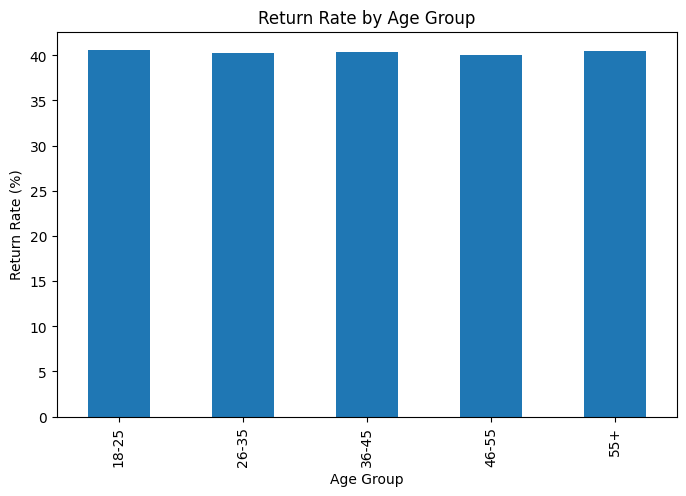

In [27]:
plt.figure(figsize=(8,5))
age_group_returns.plot(kind='bar')
plt.title('Return Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Return Rate (%)')
plt.show()

In [28]:
# Return Rate by Payment Method
payment_return = data.groupby('Payment Method')['Returns'].mean() * 100
print("\nReturn Rate by Payment Method:")
print(payment_return)
# Highest Return Payment Method
highest_payment_method = payment_return.idxmax()
highest_return_rate = payment_return.max()
print(f"Payment Method with Highest Return Rate: {highest_payment_method}")
print(f"Return Rate: {highest_return_rate:.2f}%")


Return Rate by Payment Method:
Payment Method
Cash           40.602114
Credit Card    40.350595
Crypto         39.574746
PayPal         40.364305
Name: Returns, dtype: float64
Payment Method with Highest Return Rate: Cash
Return Rate: 40.60%


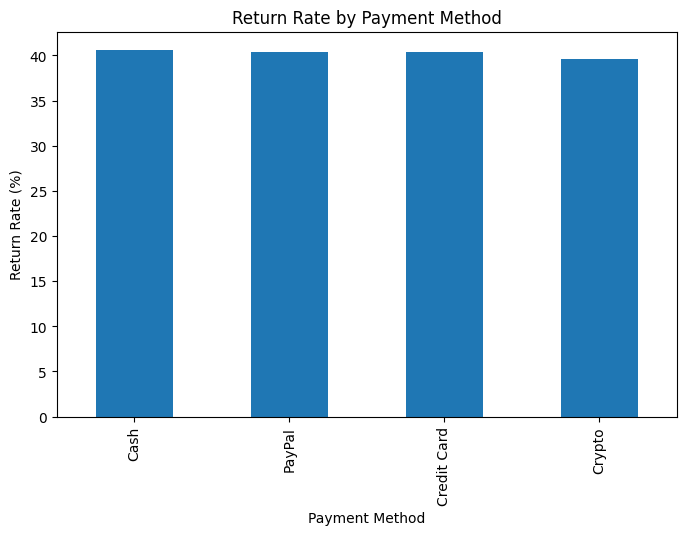

In [29]:
plt.figure(figsize=(8,5))
payment_return.sort_values(ascending=False).plot(kind='bar')
plt.title('Return Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Return Rate (%)')
plt.show()